# Forecast Analysis — demonstração do pipeline

Notebook de análise e visualização do pipeline de previsão mensal por SKU (M5).

Executa o mesmo fluxo de `src/main.py` (dados → features → split → treino MLP → baselines → métricas) e gera gráficos comparando **MLP** vs **baselines** no período de teste.

```bash
uv run jupyter notebook notebooks/forecast_analysis.ipynb
```

Pré-requisito: `make extract-data` (dataset em `data/m5/processed/`).


In [9]:
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from baselines import BASELINE_MODEL_NAMES, forecast_baselines
from config import default_config
from data.reader import load_sales_data, validate_sales_schema
from evaluation.metrics import evaluate_predictions, format_metrics_table, mae
from inference.predict import predict
from models.neural import NeuralModel
from preprocess.scaler import scale_features, scale_target, unscale_target
from preprocess.split import time_based_split
from preprocess.transform import (
    MONTH_COLUMN,
    SKU_COLUMN,
    TARGET_AHEAD_COLUMN,
    TARGET_COLUMN,
    build_dataset,
    preprocess_series,
)
from train.dataloader import make_loader
from train.trainer import train_model
from utils import get_device, set_seed

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 30)

config = default_config()
device = get_device()

print(f"Project root : {PROJECT_ROOT}")
print(f"Device       : {device}")
print(f"Reference    : {config.reference_month}")
print(f"Hidden dims  : {config.hidden_dims}")
print(f"Loss         : {config.loss}")
print(f"Seed         : {config.seed}")


Project root : /Users/alissonrodrigues/personal/forecasting-project
Device       : mps
Reference    : 2015-06
Hidden dims  : (256, 128, 64, 32)
Loss         : mae
Seed         : 42


## 1. Pipeline — mesmos passos de `main.py`

1. Carregar e validar dados
2. Agregar mensalmente e criar features
3. Split temporal (treino / validação / teste)
4. Escalar features e target
5. Treinar MLP
6. Gerar previsões baseline (StatsForecast)
7. Avaliar no período de teste


In [10]:
# [1/7] Load and validate data
raw = validate_sales_schema(load_sales_data(str(config.data_path)))
print(f"[1/7] Loaded {len(raw):,} daily rows")

# [2/7] Build monthly features and supervised dataset
monthly = preprocess_series(raw)
supervised, feature_columns = build_dataset(
    monthly,
    lags=config.lags,
    rolling_windows=config.rolling_windows,
    horizon=config.forecast_horizon,
)
print(
    f"[2/7] Monthly={len(monthly):,} | Supervised={len(supervised):,} | "
    f"Features={len(feature_columns)}"
)

# [3/7] Split by reference month
(X_train, y_train), (X_val, y_val), (X_test, y_test), test_target_dates = time_based_split(
    supervised,
    date_column=MONTH_COLUMN,
    feature_columns=feature_columns,
    target_column=TARGET_AHEAD_COLUMN,
    reference_month=config.reference_month,
    validation_months=config.validation_months,
    forecast_horizon=config.forecast_horizon,
)
print(f"[3/7] Partitions: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")

# [4/7] Scale features and targets
X_train_pp, X_val_pp, X_test_pp = scale_features(X_train, X_val, X_test, method="standardize")
y_train_s, y_val_s, _, y_loc, y_scale = scale_target(y_train, y_val, y_test)
print("[4/7] Features and targets scaled")

# [5/7] Train neural network
set_seed(config.seed)
train_loader = make_loader(
    X_train_pp, y_train_s, batch_size=config.batch_size, shuffle=True, seed=config.seed,
)
val_loader = make_loader(X_val_pp, y_val_s, batch_size=config.batch_size, shuffle=False)
model = NeuralModel(
    input_dim=X_train_pp.shape[1],
    hidden_dims=config.hidden_dims,
    dropout=config.dropout,
)
model = train_model(
    model,
    train_loader,
    val_loader,
    device=device,
    epochs=config.epochs,
    learning_rate=config.learning_rate,
    weight_decay=config.weight_decay,
    patience=config.patience,
    loss=config.loss,
)
print("[5/7] MLP training complete")

# [6/7] Baseline forecasts
mlp_preds = unscale_target(predict(model, X_test_pp, device), y_loc, y_scale)
baseline_preds = forecast_baselines(
    monthly, supervised, config.reference_month, config.forecast_horizon,
)
all_preds = {"MLP": mlp_preds, **baseline_preds}
print(f"[6/7] Baselines generated: {', '.join(BASELINE_MODEL_NAMES)}")

# [7/7] Build test dataframe for plotting
test_df = supervised.loc[test_target_dates.index].copy()
test_df["target_date"] = test_target_dates.values
test_df["y_true"] = y_test
for name, preds in all_preds.items():
    test_df[name] = preds

metrics_df = evaluate_predictions(y_test, all_preds)
test_months = test_target_dates.dt.to_period("M")
print(
    f"[7/7] Test scope: {len(y_test)} rows, "
    f"{test_months.nunique()} months ({test_months.min()} → {test_months.max()})"
)
print()
print(format_metrics_table(metrics_df))


[1/7] Loaded 933,648 daily rows
[2/7] Monthly=3,148 | Supervised=2,498 | Features=20
[3/7] Partitions: train=1548, val=300, test=650
[4/7] Features and targets scaled
[5/7] MLP training complete
[6/7] Baselines generated: Naive, WindowAverage_3, WindowAverage_6, WindowAverage_12, SeasonalNaive_12
[7/7] Test scope: 650 rows, 13 months (2015-06 → 2016-06)

model                       mae       rmse   mae/mean      %bias
MLP                      779.81    1284.18     0.1961     -2.27%
Naive                    824.90    1490.77     0.2074      1.46%
WindowAverage_12         913.09    1355.13     0.2296     -0.94%
SeasonalNaive_12         929.33    1402.74     0.2337      0.08%
WindowAverage_3          943.06    1501.97     0.2372      0.44%
WindowAverage_6          945.53    1468.16     0.2378     -1.00%


## 2. Comparação global de métricas

Barras com MAE, RMSE e %bias por modelo, além da distribuição do erro absoluto nas linhas de teste.


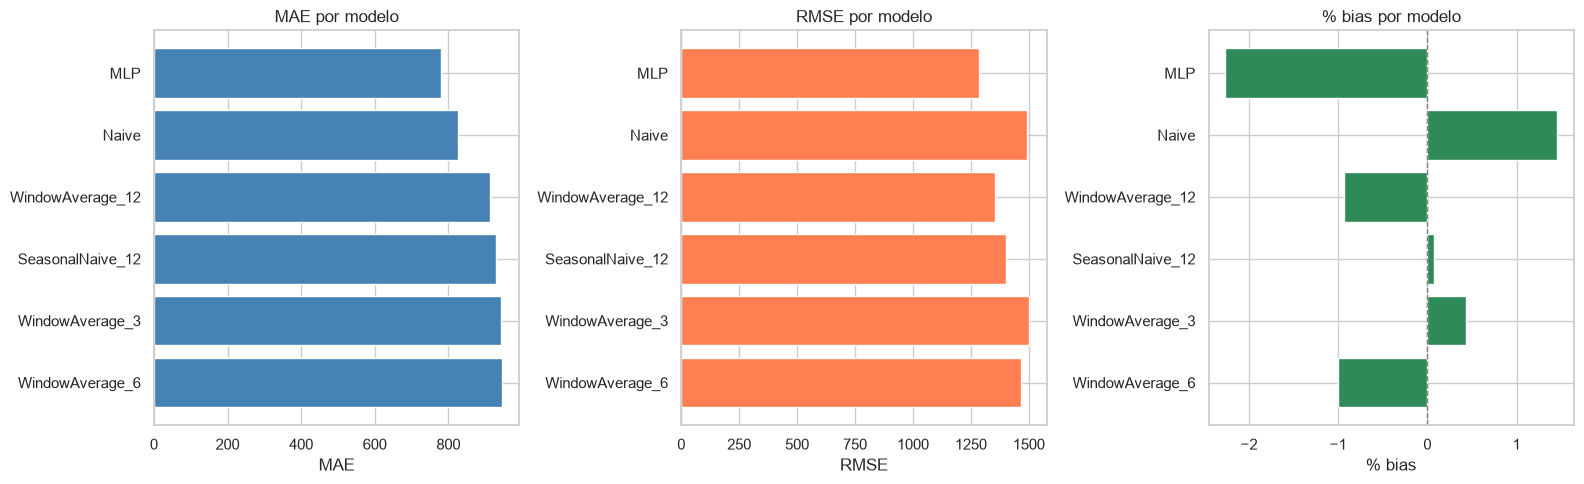

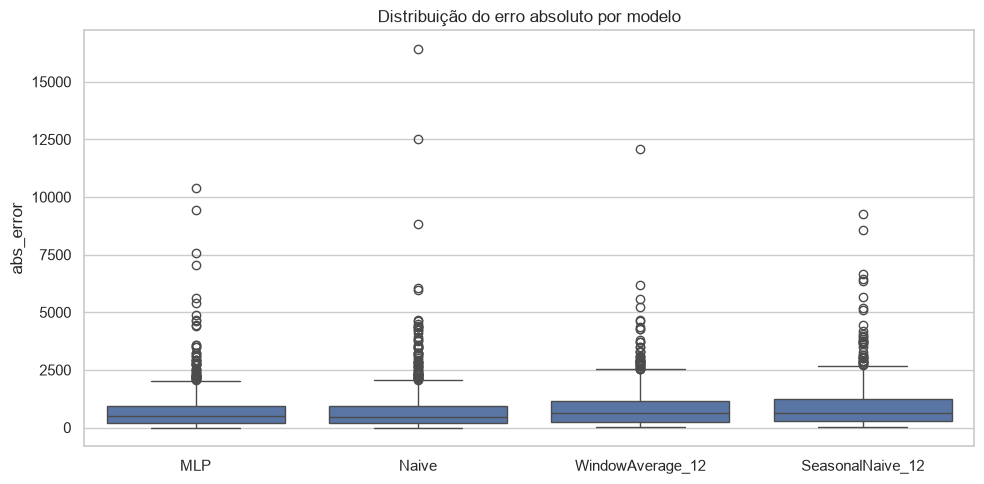

In [11]:
PLOT_MODELS = ["MLP", "Naive", "WindowAverage_12", "SeasonalNaive_12"]

for name in PLOT_MODELS:
    test_df[f"abs_err_{name}"] = np.abs(test_df["y_true"] - test_df[name])

ordered = metrics_df.sort_values("mae")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(ordered["model"], ordered["mae"], color="steelblue")
axes[0].set_xlabel("MAE")
axes[0].set_title("MAE por modelo")
axes[0].invert_yaxis()

axes[1].barh(ordered["model"], ordered["rmse"], color="coral")
axes[1].set_xlabel("RMSE")
axes[1].set_title("RMSE por modelo")
axes[1].invert_yaxis()

axes[2].barh(ordered["model"], ordered["pct_bias"], color="seagreen")
axes[2].set_xlabel("% bias")
axes[2].set_title("% bias por modelo")
axes[2].invert_yaxis()
axes[2].axvline(0, color="gray", ls="--", lw=1)

plt.tight_layout()
plt.show()

err_cols = [f"abs_err_{m}" for m in PLOT_MODELS]
err_long = test_df[err_cols].melt(var_name="model", value_name="abs_error")
err_long["model"] = err_long["model"].str.replace("abs_err_", "")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=err_long, x="model", y="abs_error", order=PLOT_MODELS, ax=ax)
ax.set_title("Distribuição do erro absoluto por modelo")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 3. Real vs previsto

Dispersão entre demanda real e previsões (MLP e Naive), limitada ao percentil 99 para legibilidade.


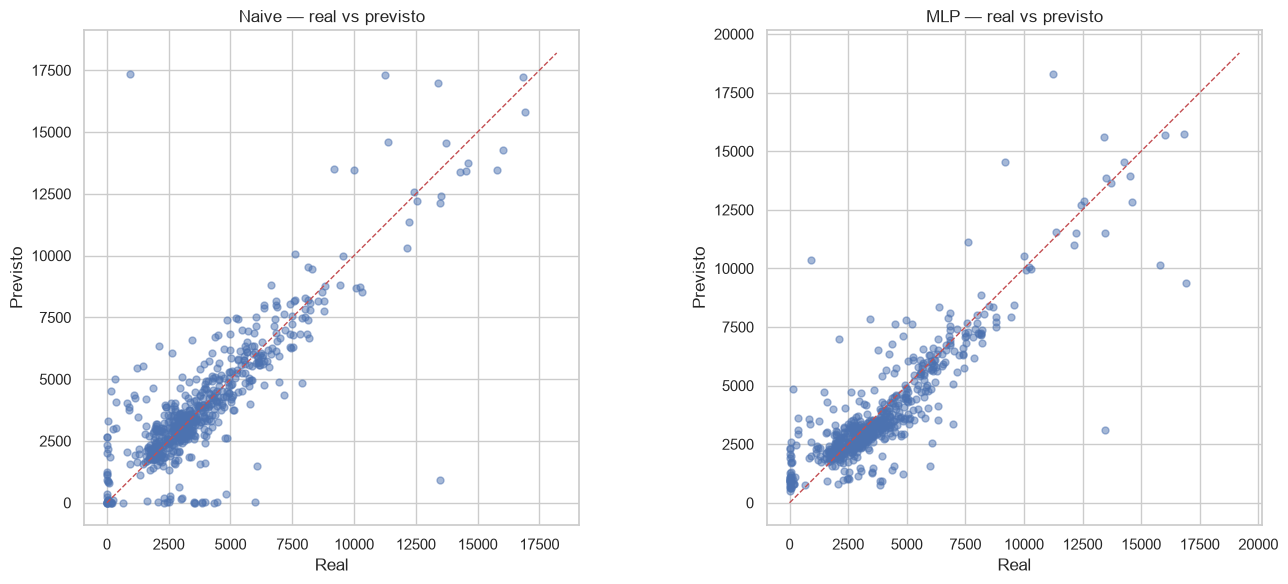

In [12]:
cap = np.percentile(test_df["y_true"], 99)
mask = test_df["y_true"] <= cap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, model_name in zip(axes, ["Naive", "MLP"]):
    subset = test_df.loc[mask]
    ax.scatter(subset["y_true"], subset[model_name], alpha=0.5, s=25)
    lim = max(subset["y_true"].max(), subset[model_name].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", lw=1)
    ax.set_xlabel("Real")
    ax.set_ylabel("Previsto")
    ax.set_title(f"{model_name} — real vs previsto")
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


## 4. MAE por SKU (top 10 por demanda no teste)

Comparação de MAE entre MLP e Naive nos SKUs com maior volume no período de teste.


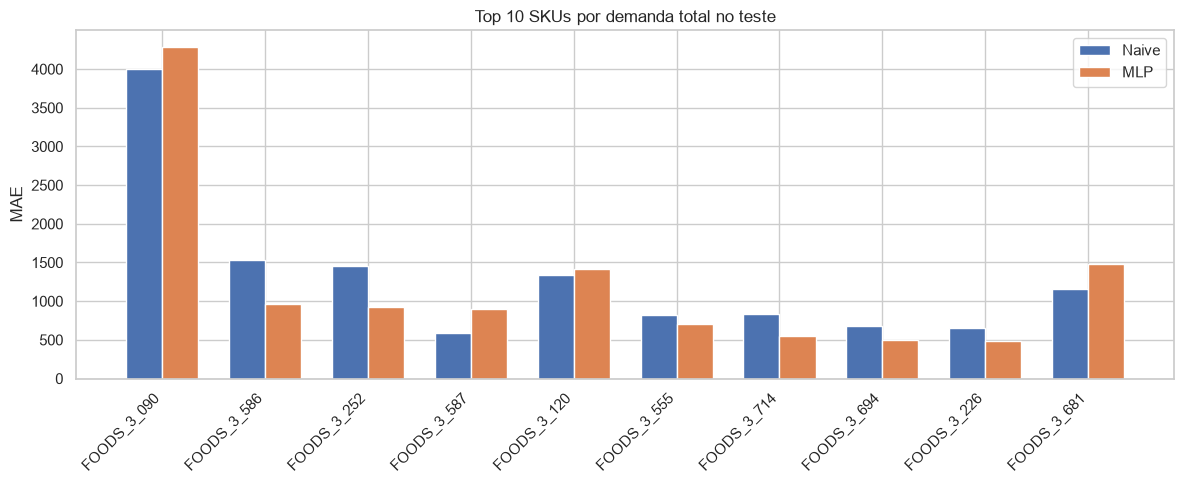

,item_id,mae_naive,mae_mlp,mean_demand,total_demand
7,FOODS_3_090,3997.230769,4284.786785,14665.461538,190651.0
32,FOODS_3_586,1537.769231,958.444199,13449.692308,174846.0
13,FOODS_3_252,1457.230769,924.599938,9395.153846,122137.0
33,FOODS_3_587,593.153846,897.228372,7336.230769,95371.0
9,FOODS_3_120,1344.000000,1419.914730,7280.153846,94642.0
31,FOODS_3_555,817.538462,701.728785,6925.000000,90025.0
39,FOODS_3_714,839.769231,547.068987,5912.000000,76856.0
37,FOODS_3_694,684.384615,493.486341,5888.846154,76555.0
11,FOODS_3_226,653.538462,485.218377,5820.769231,75670.0
36,FOODS_3_681,1157.538462,1479.341722,5320.769231,69170.0


In [13]:
sku_metrics = (
    test_df.groupby(SKU_COLUMN)
    .apply(
        lambda g: pd.Series(
            {
                "mae_naive": mae(g["y_true"], g["Naive"]),
                "mae_mlp": mae(g["y_true"], g["MLP"]),
                "mean_demand": g["y_true"].mean(),
                "total_demand": g["y_true"].sum(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
    .sort_values("total_demand", ascending=False)
)

top = sku_metrics.head(10)
x = np.arange(len(top))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, top["mae_naive"], width, label="Naive")
ax.bar(x + width / 2, top["mae_mlp"], width, label="MLP")
ax.set_xticks(x)
ax.set_xticklabels(top[SKU_COLUMN], rotation=45, ha="right")
ax.set_ylabel("MAE")
ax.set_title("Top 10 SKUs por demanda total no teste")
ax.legend()
plt.tight_layout()
plt.show()

sku_metrics.head(10)


## 5. Séries temporais — MLP vs Naive

Gráficos das principais séries com histórico recente, valores reais no teste (pontos pretos) e previsões do **Naive** e da **MLP** (linhas tracejadas).


In [14]:
FORECAST_MODELS = ["Naive", "MLP"]
MODEL_STYLES = {
    "Naive": {"color": "#2ca02c", "marker": "^", "label": "Naive"},
    "MLP": {"color": "#d62728", "marker": "s", "label": "MLP"},
}
HIST_MONTHS = 18
TOP_N_GRID = 8
TOP_N_DETAIL = 5


def plot_sku_forecasts(
    sku: str,
    title_suffix: str = "",
    hist_months: int = HIST_MONTHS,
    models: list[str] = FORECAST_MODELS,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    hist = monthly[monthly[SKU_COLUMN] == sku].sort_values(MONTH_COLUMN)
    test_sku = test_df[test_df[SKU_COLUMN] == sku].sort_values("target_date")
    test_start = test_sku["target_date"].min()
    hist_tail = hist[hist[MONTH_COLUMN] >= test_start - pd.DateOffset(months=hist_months)]

    if ax is None:
        _, ax = plt.subplots(figsize=(13, 4.5))

    ax.plot(
        hist_tail[MONTH_COLUMN],
        hist_tail[TARGET_COLUMN],
        color="#444444",
        lw=1.5,
        marker="o",
        ms=3,
        alpha=0.55,
        label="histórico",
    )
    ax.scatter(
        test_sku["target_date"],
        test_sku["y_true"],
        c="black",
        s=55,
        zorder=6,
        label="real (teste)",
    )

    for model_name in models:
        style = MODEL_STYLES[model_name]
        ax.plot(
            test_sku["target_date"],
            test_sku[model_name],
            ls="--",
            lw=2.0,
            marker=style["marker"],
            ms=5,
            color=style["color"],
            label=style["label"],
        )

    ax.axvline(test_start, color="gray", ls=":", lw=1.2)
    mae_naive = mae(test_sku["y_true"], test_sku["Naive"])
    mae_mlp = mae(test_sku["y_true"], test_sku["MLP"])
    ax.set_title(
        f"{sku} {title_suffix}\nMAE teste — Naive: {mae_naive:.0f} | MLP: {mae_mlp:.0f}",
        fontsize=11,
    )
    ax.set_xlabel("Mês")
    ax.set_ylabel("Demanda")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left", fontsize=9)
    return ax


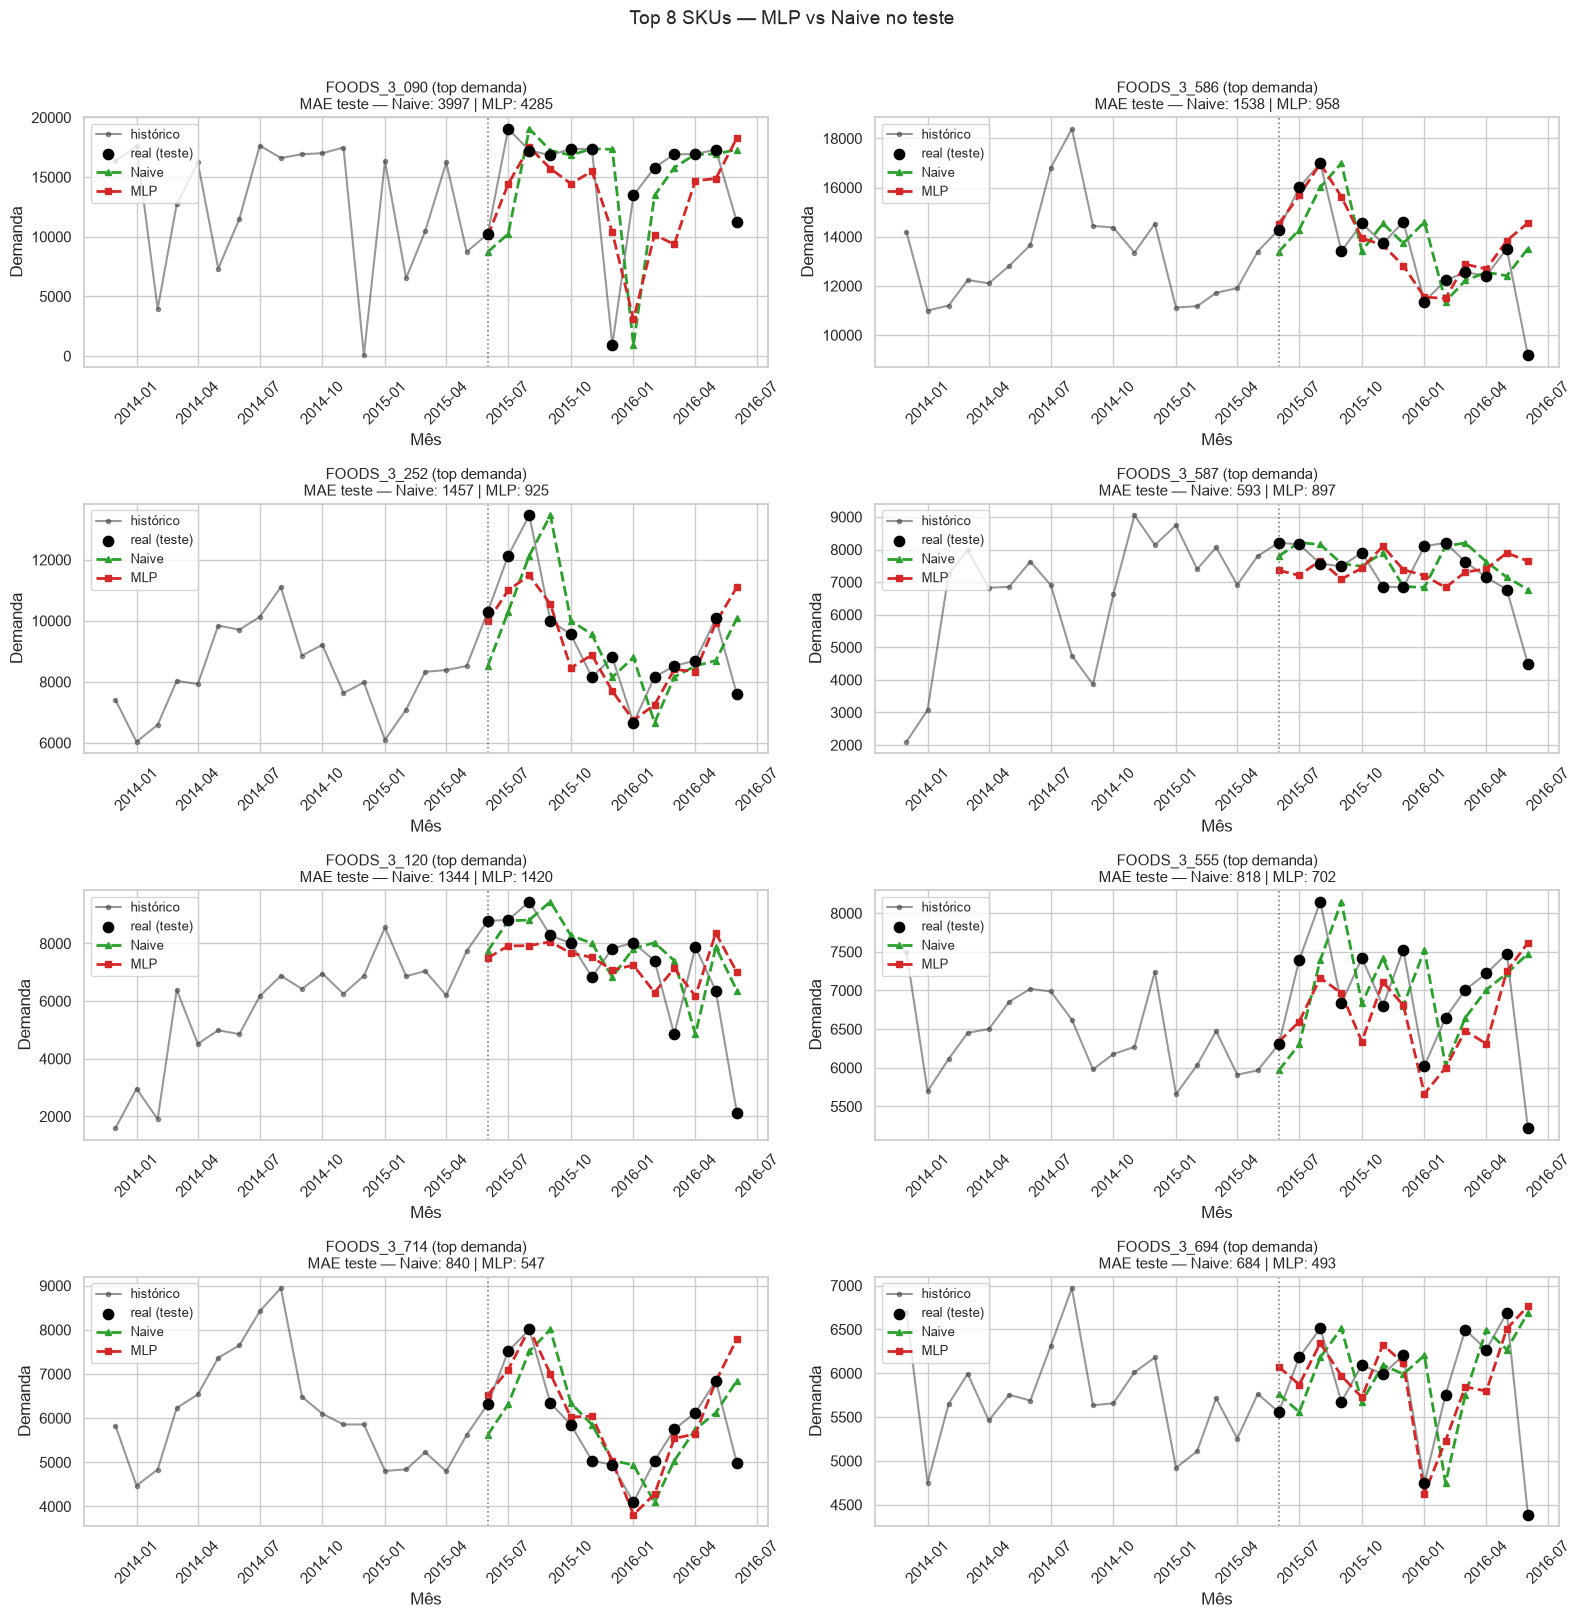

In [15]:
top_skus = sku_metrics.head(TOP_N_GRID)[SKU_COLUMN].tolist()

ncols = 2
nrows = TOP_N_GRID // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, sku in zip(axes, top_skus):
    plot_sku_forecasts(sku, title_suffix="(top demanda)", ax=ax)

for ax in axes[len(top_skus):]:
    ax.axis("off")

fig.suptitle(
    f"Top {TOP_N_GRID} SKUs — MLP vs Naive no teste",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()


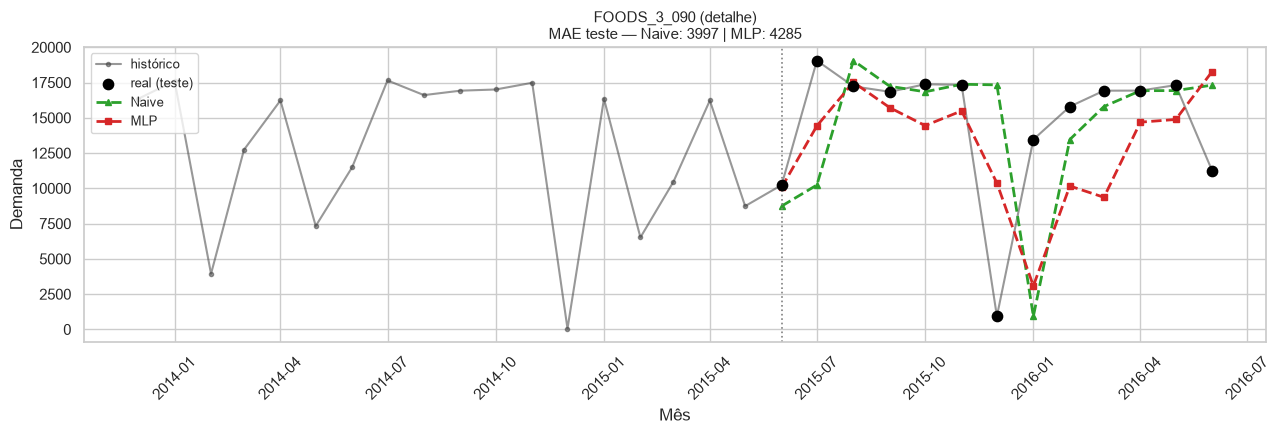

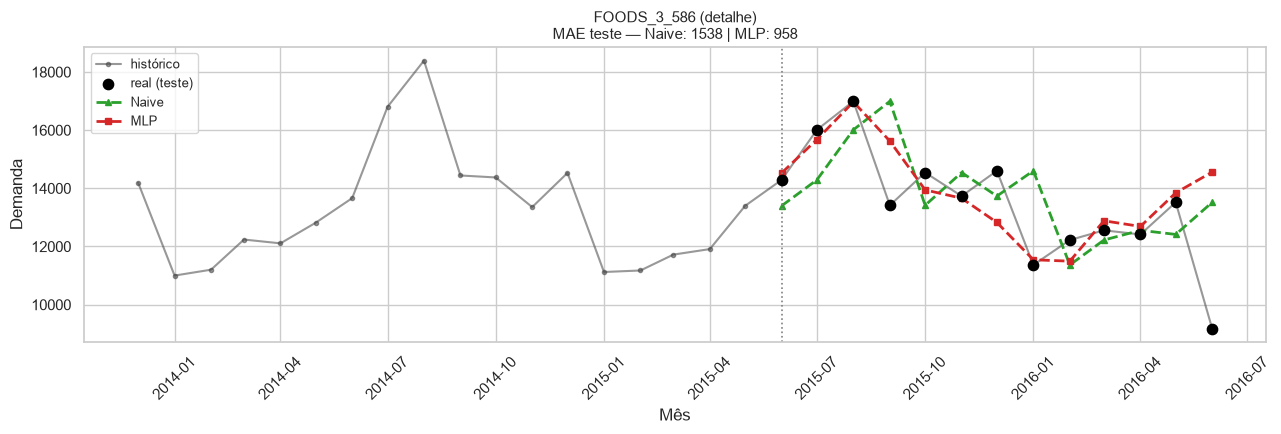

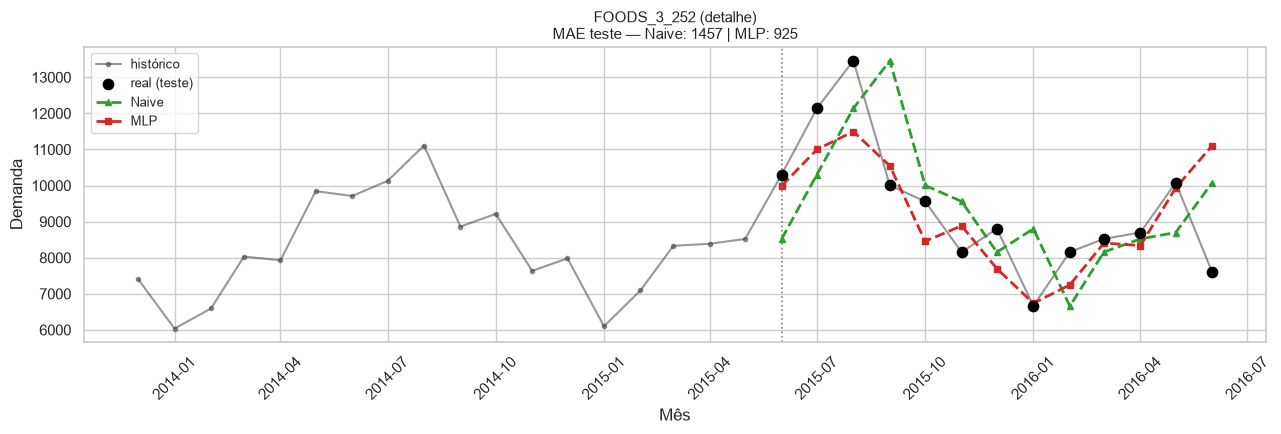

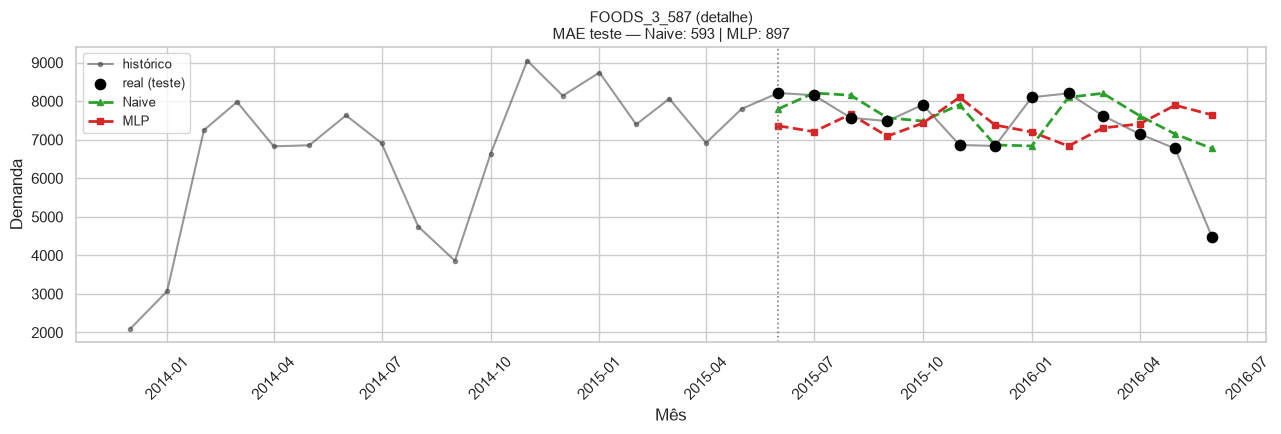

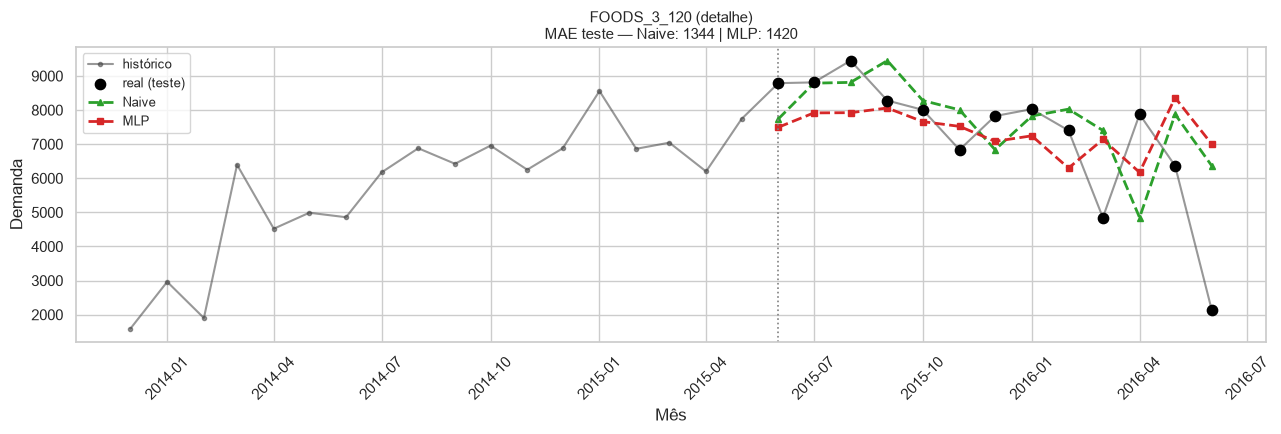

In [16]:
for sku in sku_metrics.head(TOP_N_DETAIL)[SKU_COLUMN]:
    plot_sku_forecasts(sku, title_suffix="(detalhe)")
    plt.tight_layout()
    plt.show()
